# 1 - Guide la gestion des délais de publication dans `tsforecast.delays`

Ce notebook illustre les fonctionnalités du module `tsforecast.delays`, qui fournit des outils pour la gestion des délais publication de séries temporelles.

## Importation des modules

In [1]:
# Modules de base
import pandas as pd
import numpy as np
import sys
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import timedelta
warnings.filterwarnings('ignore')

# Ajout du chemin
sys.path.append('..')

# Modules du package
from tsforecast.delays.data_manager import compare_and_detect_delays, _validate_input_data
from tsforecast.delays.calculator import calculate_applicable_delay

## Génération de données synthétiques

### Génération de jeux de données de séries temporelles

In [2]:
# Initialisation d'un seed pour la reproductabilité
np.random.seed(42)

# Création de dates mensuelles et trimestrielles entre 2020 et 2024
monthly_dates = pd.date_range('2020-01-01', '2024-01-01', freq='MS')
quarterly_dates = pd.date_range('2020-01-01', '2024-01-01', freq='QS')

# Fonction de génération de séries
def generate_economic_series(dates, base_value=100, trend=0.02, volatility=0.05):
    """Generate realistic economic time series"""
    n = len(dates)
    # Composante tendancielle
    trend_component = np.cumsum(np.random.normal(trend/12, volatility/4, n))
    # Composante cyclique
    cycle = 0.1 * np.sin(2 * np.pi * np.arange(n) / 12) 
    # Bruit gaussien
    noise = np.random.normal(0, volatility, n)
    
    return base_value * np.exp(trend_component + cycle + noise)

# Génération d'indicateurs mensuels
monthly_data = pd.DataFrame({
    'date': monthly_dates,
    'country': 'US',
    'inflation_rate': generate_economic_series(monthly_dates, 2.0, 0.001, 0.02),
    'unemployment_rate': generate_economic_series(monthly_dates, 5.0, -0.001, 0.03),
    'industrial_production': generate_economic_series(monthly_dates, 100, 0.002, 0.04)
})

# Génération d'indicateurs trimestriels
quarterly_data = pd.DataFrame({
    'date': quarterly_dates,
    'country': 'US', 
    'gdp_growth': generate_economic_series(quarterly_dates, 2.5, 0.0005, 0.015),
    'government_debt': generate_economic_series(quarterly_dates, 80, 0.01, 0.02)
})

print("Monthly data shape:", monthly_data.shape)
print("Quarterly data shape:", quarterly_data.shape)
print("\nMonthly data sample:")
print(monthly_data.head())
print("\nQuarterly data sample:")
print(quarterly_data.head())

Monthly data shape: (49, 5)
Quarterly data shape: (17, 4)

Monthly data sample:
        date country  inflation_rate  unemployment_rate  industrial_production
0 2020-01-01      US        1.935670           4.805587              97.818941
1 2020-02-01      US        2.120364           5.329239             102.432535
2 2020-03-01      US        2.175653           5.432306             105.574865
3 2020-04-01      US        2.209106           5.480127             116.548335
4 2020-05-01      US        2.234182           5.408413             109.315070

Quarterly data sample:
        date country  gdp_growth  government_debt
0 2020-01-01      US    2.545057        80.690558
1 2020-04-01      US    2.657792        82.351275
2 2020-07-01      US    2.765814        85.556844
3 2020-10-01      US    2.827254        87.593422
4 2021-01-01      US    2.744863        87.410966


### Génération de jeux de données de panel

In [3]:
# Génération de données de panel multi-pays
countries = ['US', 'UK', 'FR', 'DE']
panel_monthly_list = []
panel_quarterly_list = []

for i, country in enumerate(countries):
    # Variation des seed pour avoir des données différentes par pays
    np.random.seed(42 + i)
    
    # Données mensuelles par pays avec des caractéristiques différentes
    monthly_panel = pd.DataFrame({
        'date': monthly_dates,
        'country': country,
        'inflation_rate': generate_economic_series(monthly_dates, 2.0 + i*0.3, 0.001, 0.02 + i*0.005),
        'unemployment_rate': generate_economic_series(monthly_dates, 5.0 + i*0.5, -0.001, 0.03),
    })
    panel_monthly_list.append(monthly_panel)
    
    # Données trimestrielles par pays
    quarterly_panel = pd.DataFrame({
        'date': quarterly_dates,
        'country': country,
        'gdp_growth': generate_economic_series(quarterly_dates, 2.5 + i*0.2, 0.0005, 0.015),
    })
    panel_quarterly_list.append(quarterly_panel)

# Concaténation
panel_monthly_data = pd.concat(panel_monthly_list, ignore_index=True)
panel_quarterly_data = pd.concat(panel_quarterly_list, ignore_index=True)

print("Panel monthly data shape:", panel_monthly_data.shape)
print("Panel quarterly data shape:", panel_quarterly_data.shape)
print("\nPanel monthly data sample (multiple countries):")
print(panel_monthly_data.groupby('country').head(2))
print("\nCountries in panel:", panel_monthly_data['country'].unique())

Panel monthly data shape: (196, 4)
Panel quarterly data shape: (68, 3)

Panel monthly data sample (multiple countries):
          date country  inflation_rate  unemployment_rate
0   2020-01-01      US        1.935670           4.805587
1   2020-02-01      US        2.120364           5.329239
49  2020-01-01      UK        2.362878           5.572339
50  2020-02-01      UK        2.391200           5.872431
98  2020-01-01      FR        2.694246           6.069473
99  2020-02-01      FR        2.833972           6.035710
147 2020-01-01      DE        2.767974           6.293467
148 2020-02-01      DE        3.030297           6.821689

Countries in panel: ['US' 'UK' 'FR' 'DE']


## 1. Détection des délais de publication (`compare_and_detect_delays`)

### 1.1 Préparation des données de simulation

In [4]:
# Simulation de données "existantes" vs "nouvelles" pour illustrer la détection de délais
# Scénario: nous sommes le 15 septembre 2023, et nous téléchargeons de nouvelles données

# Pour les séries temporelles simples (US uniquement)
# Données existantes: jusqu'à juin 2023 (mensuel) et Q1 2023 (trimestriel)
existing_monthly = monthly_data[monthly_data['date'] <= '2023-06-01'].copy()
existing_quarterly = quarterly_data[quarterly_data['date'] <= '2023-04-01'].copy()

# Nouvelles données: ajout de juillet-août 2023 (mensuel) et Q2 2023 (trimestriel)
new_monthly = monthly_data[monthly_data['date'] <= '2023-08-01'].copy()
new_quarterly = quarterly_data[quarterly_data['date'] <= '2023-07-01'].copy()

# Pour les données de panel
existing_panel_monthly = panel_monthly_data[panel_monthly_data['date'] <= '2023-06-01'].copy()
new_panel_monthly = panel_monthly_data[panel_monthly_data['date'] <= '2023-08-01'].copy()

print("=== Time Series Data ===")
print("Existing monthly data ends:", existing_monthly['date'].max())
print("New monthly data ends:", new_monthly['date'].max())
print("→ New observations:", len(new_monthly) - len(existing_monthly))
print()
print("Existing quarterly data ends:", existing_quarterly['date'].max())
print("New quarterly data ends:", new_quarterly['date'].max())
print("→ New observations:", len(new_quarterly) - len(existing_quarterly))
print()
print("=== Panel Data ===")
print("Existing panel monthly data ends:", existing_panel_monthly['date'].max())
print("New panel monthly data ends:", new_panel_monthly['date'].max())
print("→ New observations:", len(new_panel_monthly) - len(existing_panel_monthly))

=== Time Series Data ===
Existing monthly data ends: 2023-06-01 00:00:00
New monthly data ends: 2023-08-01 00:00:00
→ New observations: 2

Existing quarterly data ends: 2023-04-01 00:00:00
New quarterly data ends: 2023-07-01 00:00:00
→ New observations: 1

=== Panel Data ===
Existing panel monthly data ends: 2023-06-01 00:00:00
New panel monthly data ends: 2023-08-01 00:00:00
→ New observations: 8


### 1.2. Cas de base: Détection simple avec visualisation du concept

Dans cet exemple, nous allons détecter les nouvelles publications dans les données mensuelles avec les paramètres par défaut et visualiser le concept de délai de publication.

In [5]:
# Définition de la date de téléchargement (15 septembre 2023)
download_date = '2023-09-15'

# Préparation des DataFrames pour la comparaison (format large avec date en index)
existing_df = existing_monthly.set_index('date')[['inflation_rate', 'unemployment_rate', 'industrial_production']]
new_df = new_monthly.set_index('date')[['inflation_rate', 'unemployment_rate', 'industrial_production']]

# Détection des délais avec paramètres par défaut
# detection_mode='new_only': détecte uniquement les nouvelles publications (null → non-null)
# reference_point='end': calcule le délai depuis la fin de la période
# delay_unit='day': délais exprimés en jours
delays_basic = compare_and_detect_delays(
    new_data=new_df,
    existing_data=existing_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='day'
)

print("Délais détectés:")
print(delays_basic)
print("\n" + "="*80)
print("Interprétation:")
print("- has_changes=True: Nouvelle publication détectée")
print("- release_delay: Nombre de jours entre la date de référence et la date de téléchargement")
print("- period_end: Fin de la période d'observation (reference_point='end')")

Délais détectés:
                      observation_date  has_changes download_date frequency  \
column                                                                        
unemployment_rate           2023-07-01         True    2023-09-15   monthly   
unemployment_rate           2023-08-01         True    2023-09-15   monthly   
inflation_rate              2023-07-01         True    2023-09-15   monthly   
inflation_rate              2023-08-01         True    2023-09-15   monthly   
industrial_production       2023-07-01         True    2023-09-15   monthly   
industrial_production       2023-08-01         True    2023-09-15   monthly   

                      period_start period_end reference_point  release_delay  \
column                                                                         
unemployment_rate       2023-07-01 2023-08-01             end           45.0   
unemployment_rate       2023-08-01 2023-09-01             end           14.0   
inflation_rate          2023-0

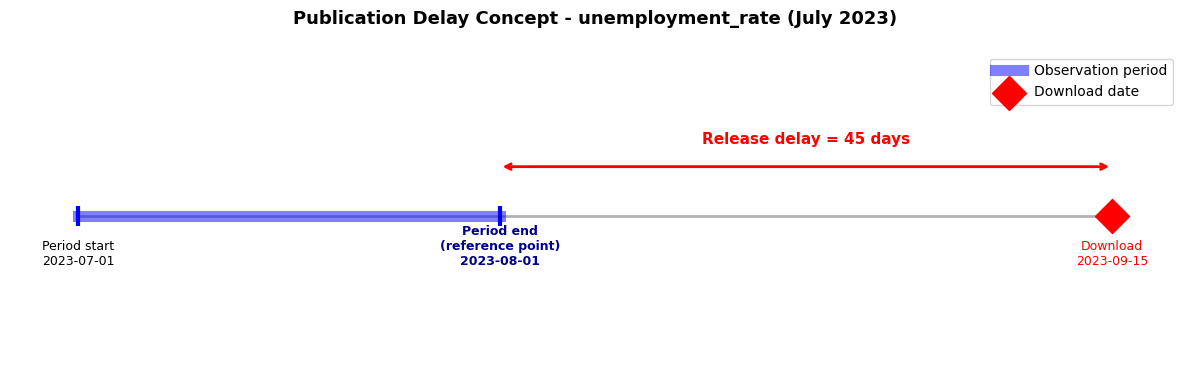


Explanation:
The data for July 2023 was published on 2023-09-15,
which is 45 days after the end of the observation period (2023-08-01).


In [6]:
# Visualisation du concept de délai de publication pour une observation
# Prenons la première observation: juillet 2023 pour inflation_rate

example_row = delays_basic.iloc[0]
obs_date = example_row["observation_date"]  # Date d'observation
indicator = example_row.name # Nom de l'indicateur
period_start = example_row['period_start']
period_end = example_row['period_end']
download = pd.Timestamp(example_row['download_date'])
delay_days = example_row['release_delay']

# Conversion de obs_date en datetime si c'est un string
obs_date = pd.to_datetime(obs_date) if isinstance(obs_date, str) else obs_date

fig, ax = plt.subplots(figsize=(12, 4))

# Timeline
y_pos = 0
ax.plot([period_start, download], [y_pos, y_pos], 'k-', linewidth=2, alpha=0.3)

# Période d'observation
ax.plot([period_start, period_end], [y_pos, y_pos], 'b-', linewidth=8, alpha=0.5, label='Observation period')
ax.scatter([period_start], [y_pos], s=200, c='blue', marker='|', linewidth=3)
ax.scatter([period_end], [y_pos], s=200, c='blue', marker='|', linewidth=3)

# Date de téléchargement
ax.scatter([download], [y_pos], s=300, c='red', marker='D', zorder=5, label='Download date')

# Délai de publication
ax.annotate('', xy=(download, y_pos + 0.15), xytext=(period_end, y_pos + 0.15),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text((period_end + (download - period_end)/2), y_pos + 0.22, 
        f'Release delay = {delay_days:.0f} days', 
        ha='center', fontsize=11, color='red', fontweight='bold')

# Labels
ax.text(period_start, y_pos - 0.15, f'Period start\n{period_start.strftime("%Y-%m-%d")}', 
        ha='center', fontsize=9)
ax.text(period_end, y_pos - 0.15, f'Period end\n(reference point)\n{period_end.strftime("%Y-%m-%d")}', 
        ha='center', fontsize=9, color='darkblue', fontweight='bold')
ax.text(download, y_pos - 0.15, f'Download\n{download.strftime("%Y-%m-%d")}', 
        ha='center', fontsize=9, color='red')

ax.set_ylim(-0.5, 0.5)
ax.set_xlim(period_start - timedelta(days=5), download + timedelta(days=5))
ax.axis('off')
ax.legend(loc='upper right', fontsize=10)
ax.set_title(f'Publication Delay Concept - {indicator} ({obs_date.strftime("%B %Y")})', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"\nExplanation:")
print(f"The data for {obs_date.strftime('%B %Y')} was published on {download.strftime('%Y-%m-%d')},")
print(f"which is {delay_days:.0f} days after the end of the observation period ({period_end.strftime('%Y-%m-%d')}).")

### 1.3. Impact du paramètre `reference_point`

Le paramètre `reference_point` détermine le point de référence pour calculer le délai de publication:
- `'start'`: Délai calculé depuis le **début** de la période d'observation
- `'end'`: Délai calculé depuis la **fin** de la période d'observation

Cette différence peut être significative (environ 30 jours pour des données mensuelles).

In [7]:
# Comparaison des deux reference_point: 'start' vs 'end'

delays_ref_start = compare_and_detect_delays(
    new_data=new_df,
    existing_data=existing_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='start',  # Référence = début de période
    delay_unit='day'
)

delays_ref_end = compare_and_detect_delays(
    new_data=new_df,
    existing_data=existing_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',  # Référence = fin de période
    delay_unit='day'
)

# Création d'un tableau comparatif
comparison = pd.DataFrame({
    'observation_date': [idx for idx in delays_ref_start['observation_date']],
    'indicator': [idx for idx in delays_ref_start.index],
    'delay_from_start': delays_ref_start['release_delay'].values,
    'delay_from_end': delays_ref_end['release_delay'].values,
})
comparison['difference'] = comparison['delay_from_start'] - comparison['delay_from_end']

print("Comparison of reference_point='start' vs reference_point='end':")
print(comparison)
print("\n" + "="*80)
print(f"Average difference: {comparison['difference'].mean():.1f} days")
print(f"This corresponds approximately to the average month length.")

Comparison of reference_point='start' vs reference_point='end':
  observation_date              indicator  delay_from_start  delay_from_end  \
0       2023-07-01      unemployment_rate              76.0            45.0   
1       2023-08-01      unemployment_rate              45.0            14.0   
2       2023-07-01         inflation_rate              76.0            45.0   
3       2023-08-01         inflation_rate              45.0            14.0   
4       2023-07-01  industrial_production              76.0            45.0   
5       2023-08-01  industrial_production              45.0            14.0   

   difference  
0        31.0  
1        31.0  
2        31.0  
3        31.0  
4        31.0  
5        31.0  

Average difference: 31.0 days
This corresponds approximately to the average month length.


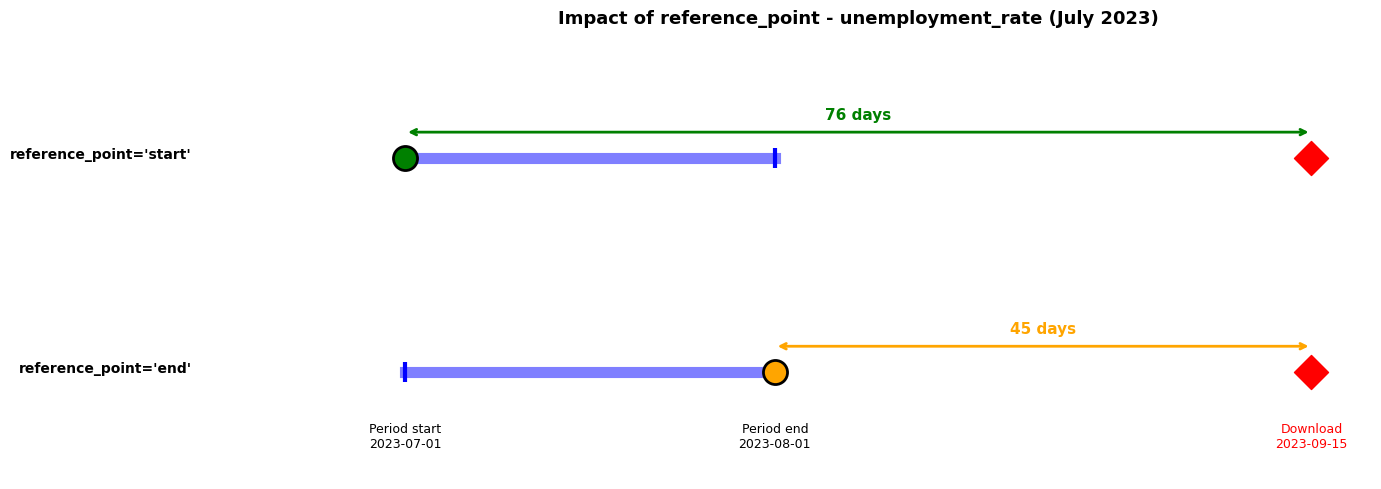


Difference: 31 days
This corresponds to the length of July 2023 (31 days)


In [8]:
# Visualisation de la différence pour un exemple
example_row_start = delays_ref_start.iloc[0]
example_row_end = delays_ref_end.iloc[0]
obs_date = example_row_start['observation_date']
indicator = example_row_start.name

# Initialisation de la figure
fig, ax = plt.subplots(figsize=(14, 5))

y_start = 1
y_end = 0

# Timeline de base
period_start = example_row_start['period_start']
period_end = example_row_start['period_end']
download = pd.Timestamp(example_row_start['download_date'])

# Ligne 1: Reference point = 'start'
ax.plot([period_start, period_end], [y_start, y_start], 'b-', linewidth=8, alpha=0.5)
ax.scatter([period_start], [y_start], s=300, c='green', marker='o', zorder=5, edgecolor='black', linewidth=2)
ax.scatter([period_end], [y_start], s=200, c='blue', marker='|', linewidth=3)
ax.scatter([download], [y_start], s=300, c='red', marker='D', zorder=5)
ax.annotate('', xy=(download, y_start + 0.12), xytext=(period_start, y_start + 0.12),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text((period_start + (download - period_start)/2), y_start + 0.18, 
        f'{example_row_start["release_delay"]:.0f} days', 
        ha='center', fontsize=11, color='green', fontweight='bold')
ax.text(-0.15, y_start, "reference_point='start'", ha='right', fontsize=10, 
        transform=ax.get_yaxis_transform(), fontweight='bold')

# Ligne 2: Reference point = 'end'
ax.plot([period_start, period_end], [y_end, y_end], 'b-', linewidth=8, alpha=0.5)
ax.scatter([period_start], [y_end], s=200, c='blue', marker='|', linewidth=3)
ax.scatter([period_end], [y_end], s=300, c='orange', marker='o', zorder=5, edgecolor='black', linewidth=2)
ax.scatter([download], [y_end], s=300, c='red', marker='D', zorder=5)
ax.annotate('', xy=(download, y_end + 0.12), xytext=(period_end, y_end + 0.12),
            arrowprops=dict(arrowstyle='<->', color='orange', lw=2))
ax.text((period_end + (download - period_end)/2), y_end + 0.18, 
        f'{example_row_end["release_delay"]:.0f} days', 
        ha='center', fontsize=11, color='orange', fontweight='bold')
ax.text(-0.15, y_end, "reference_point='end'", ha='right', fontsize=10, 
        transform=ax.get_yaxis_transform(), fontweight='bold')

# Labels communs
ax.text(period_start, -0.35, f'Period start\n{period_start.strftime("%Y-%m-%d")}', 
        ha='center', fontsize=9)
ax.text(period_end, -0.35, f'Period end\n{period_end.strftime("%Y-%m-%d")}', 
        ha='center', fontsize=9)
ax.text(download, -0.35, f'Download\n{download.strftime("%Y-%m-%d")}', 
        ha='center', fontsize=9, color='red')

ax.set_ylim(-0.5, 1.5)
ax.set_xlim(period_start - timedelta(days=5), download + timedelta(days=5))
ax.axis('off')
ax.set_title(f'Impact of reference_point - {indicator} ({obs_date.strftime("%B %Y")})', 
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

diff_days = example_row_start['release_delay'] - example_row_end['release_delay']
print(f"\nDifference: {diff_days:.0f} days")
print(f"This corresponds to the length of {obs_date.strftime('%B %Y')} ({(period_end - period_start).days} days)")

### 1.4. Impact du paramètre `detection_mode`

Le paramètre `detection_mode` contrôle quels types de changements sont détectés:
- `'new_only'`: Détecte uniquement les **nouvelles publications** (null → valeur)
- `'all_changes'`: Détecte les nouvelles publications **et les révisions** (null → valeur OU valeur → valeur différente)

Simulons un scénario avec des révisions de données.

In [9]:
# Création d'un scénario avec révisions de données
# Les données existantes contiennent des valeurs jusqu'à juin 2023
# Les nouvelles données contiennent:
#   - De nouvelles observations (juillet-août 2023)
#   - Des révisions pour mai-juin 2023 (valeurs légèrement modifiées)

existing_with_revisions = existing_monthly.copy().set_index('date')[['inflation_rate', 'unemployment_rate', 'industrial_production']]
new_with_revisions = new_monthly.copy().set_index('date')[['inflation_rate', 'unemployment_rate', 'industrial_production']]

# Simulation de révisions: modifier légèrement les valeurs de mai-juin 2023
revision_dates = ['2023-05-01', '2023-06-01']
for date_str in revision_dates:
    date = pd.Timestamp(date_str)
    if date in new_with_revisions.index:
        # Révision de +0.1 pour l'inflation_rate
        new_with_revisions.loc[date, 'inflation_rate'] = new_with_revisions.loc[date, 'inflation_rate'] * 1.05

print("Scenario created with:")
print(f"- {len(revision_dates)} revised observations (May-June 2023)")
print(f"- {len(new_with_revisions) - len(existing_with_revisions)} new observations (July-August 2023)")
print("\nRevised values:")
for date_str in revision_dates:
    date = pd.Timestamp(date_str)
    if date in existing_with_revisions.index:
        old_val = existing_with_revisions.loc[date, 'inflation_rate']
        new_val = new_with_revisions.loc[date, 'inflation_rate']
        print(f"  {date.strftime('%Y-%m-%d')}: {old_val:.6f} → {new_val:.6f} (diff: {new_val - old_val:.6f})")

Scenario created with:
- 2 revised observations (May-June 2023)
- 2 new observations (July-August 2023)

Revised values:
  2023-05-01: 2.124203 → 2.230413 (diff: 0.106210)
  2023-06-01: 2.032793 → 2.134432 (diff: 0.101640)


In [10]:
# Comparaison des deux detection_mode

# Mode 1: 'new_only' - détecte uniquement les nouvelles publications
delays_new_only = compare_and_detect_delays(
    new_data=new_with_revisions,
    existing_data=existing_with_revisions,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='day'
)

# Mode 2: 'all_changes' - détecte nouvelles publications ET révisions
delays_all_changes = compare_and_detect_delays(
    new_data=new_with_revisions,
    existing_data=existing_with_revisions,
    download_date=download_date,
    detection_mode='all_changes',
    reference_point='end',
    delay_unit='day'
)

print("="*80)
print("detection_mode='new_only' - Only new publications")
print("="*80)
print(delays_new_only)
print(f"\nNumber of detected changes: {len(delays_new_only)}")

print("\n" + "="*80)
print("detection_mode='all_changes' - New publications AND revisions")
print("="*80)
print(delays_all_changes)
print(f"\nNumber of detected changes: {len(delays_all_changes)}")

print("\n" + "="*80)
print("Difference:")
print("="*80)
print(f"Additional detections with 'all_changes': {len(delays_all_changes) - len(delays_new_only)}")
print("\nThe additional detections correspond to the revised observations (May-June 2023)")

detection_mode='new_only' - Only new publications
                      observation_date  has_changes download_date frequency  \
column                                                                        
unemployment_rate           2023-07-01         True    2023-09-15   monthly   
unemployment_rate           2023-08-01         True    2023-09-15   monthly   
inflation_rate              2023-07-01         True    2023-09-15   monthly   
inflation_rate              2023-08-01         True    2023-09-15   monthly   
industrial_production       2023-07-01         True    2023-09-15   monthly   
industrial_production       2023-08-01         True    2023-09-15   monthly   

                      period_start period_end reference_point  release_delay  \
column                                                                         
unemployment_rate       2023-07-01 2023-08-01             end           45.0   
unemployment_rate       2023-08-01 2023-09-01             end           14.0 

### 1.5. Données de panel

Lorsque vous travaillez avec des données de panel (multiples entités comme des pays), utilisez le paramètre `panel_cols` pour spécifier les colonnes d'identification des entités. La fonction va alors calculer les délais pour chaque combinaison (entité, date, indicateur).

In [11]:
# Préparation des données de panel
# Format: colonnes [date, country, indicator1, indicator2, ...]
existing_panel = existing_panel_monthly.copy()#.set_index(['date', 'country'])
new_panel = new_panel_monthly.copy()#.set_index(['date', 'country'])

print("Panel data structure:")
print("Index levels:", existing_panel.index.names)
print("Indicators:", existing_panel.columns.tolist())
print("\nSample of existing panel data:")
print(existing_panel.head(10))

# Détection des délais pour les données de panel
delays_panel = compare_and_detect_delays(
    new_data=new_panel,
    existing_data=existing_panel,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='day',
    panel_cols=['country'],  # Spécification de la colonne de panel
    time_col="date"
)

print("\n" + "="*80)
print("Delays detected for panel data:")
print("="*80)
print(delays_panel)
print(f"\nTotal detections: {len(delays_panel)}")
print(f"Countries: {delays_panel.index.get_level_values(0).unique().tolist()}")
print(f"Indicators: {delays_panel.index.get_level_values(1).unique()}")

# Affichage structuré par pays
print("\n" + "="*80)
print("Detections by country:")
print("="*80)
for country in delays_panel.index.get_level_values(1).unique():
    country_delays = delays_panel[delays_panel.index.get_level_values(1) == country]
    print(f"\n{country}: {len(country_delays)} new observations")
    print(f"  Dates: {sorted([idx.strftime('%Y-%m') for idx in country_delays["observation_date"]])}")

Panel data structure:
Index levels: [None]
Indicators: ['date', 'country', 'inflation_rate', 'unemployment_rate']

Sample of existing panel data:
        date country  inflation_rate  unemployment_rate
0 2020-01-01      US        1.935670           4.805587
1 2020-02-01      US        2.120364           5.329239
2 2020-03-01      US        2.175653           5.432306
3 2020-04-01      US        2.209106           5.480127
4 2020-05-01      US        2.234182           5.408413
5 2020-06-01      US        2.169662           5.025166
6 2020-07-01      US        2.076236           4.906368
7 2020-08-01      US        1.913755           4.689404
8 2020-09-01      US        1.860417           4.448395
9 2020-10-01      US        1.864530           4.748248

Delays detected for panel data:
                          observation_date  has_changes download_date  \
country column                                                          
DE      unemployment_rate       2023-07-01         True    

## 2. Calcul des délais applicables (`calculate_applicable_delay`)

La fonction `calculate_applicable_delay` prend en entrée les délais détectés par `compare_and_detect_delays` et calcule un délai "applicable" pour chaque indicateur en:
1. Convertissant les délais vers une fréquence et un point de référence cibles
2. Agrégeant les multiples observations en une seule valeur représentative

### 2.1. Cas de base : Calcul d'un délai applicable

À partir des délais détectés, calculons un délai applicable unique pour chaque indicateur.

In [12]:
# Utilisation des délais détectés précédemment (delays_basic)
print("Input: Publication delays detected")
print(delays_basic)
print(f"\nNumber of observations per indicator:")
print(delays_basic.groupby("column").size())

# Calcul du délai applicable avec paramètres par défaut
# target_frequency='monthly': fréquence cible
# target_reference_point='end': point de référence cible
# aggregation_method='median': méthode d'agrégation (médiane robuste aux outliers)
applicable_delays = calculate_applicable_delay(
    publication_delays=delays_basic,
    target_reference_point='end',
    target_frequency='monthly',
    aggregation_method='median'
)

print("\n" + "="*80)
print("Applicable delays calculated:")
print("="*80)
print(applicable_delays)
print("\nInterpretation:")
print("- applicable_delay: Representative delay value for each indicator")
print("- n_observations: Number of observations used to calculate the delay")
print("- aggregation_method: Method used to aggregate multiple observations")

Input: Publication delays detected
                      observation_date  has_changes download_date frequency  \
column                                                                        
unemployment_rate           2023-07-01         True    2023-09-15   monthly   
unemployment_rate           2023-08-01         True    2023-09-15   monthly   
inflation_rate              2023-07-01         True    2023-09-15   monthly   
inflation_rate              2023-08-01         True    2023-09-15   monthly   
industrial_production       2023-07-01         True    2023-09-15   monthly   
industrial_production       2023-08-01         True    2023-09-15   monthly   

                      period_start period_end reference_point  release_delay  \
column                                                                         
unemployment_rate       2023-07-01 2023-08-01             end           45.0   
unemployment_rate       2023-08-01 2023-09-01             end           14.0   
inflation_ra

### 2.2. Conversions de fréquence

La fonction permet de convertir les délais entre différentes fréquences. Le comportement dépend du sens de conversion:

**Conversion vers fréquence plus haute (ex: quarterly → monthly)**:
- Si `reference_point='start'` original: Utilise la **première** sous-période (janvier pour Q1)
- Si `reference_point='end'` original: Utilise la **dernière** sous-période (mars pour Q1)

**Conversion vers fréquence plus basse (ex: monthly → quarterly)**:
- Agrégation des délais sur la période cible

In [13]:
# Exemple 1: Conversion quarterly → monthly
# D'abord, détectons les délais pour les données trimestrielles

existing_q_df = existing_quarterly.set_index('date')[['gdp_growth', 'government_debt']]
new_q_df = new_quarterly.set_index('date')[['gdp_growth', 'government_debt']]

# Détection avec reference_point='start'
delays_q_start = compare_and_detect_delays(
    new_data=new_q_df,
    existing_data=existing_q_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='start',  # Point de référence = début du trimestre
    delay_unit='day'
)

# Détection avec reference_point='end'
delays_q_end = compare_and_detect_delays(
    new_data=new_q_df,
    existing_data=existing_q_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',  # Point de référence = fin du trimestre
    delay_unit='day'
)

print("Quarterly delays detected (reference_point='start'):")
print(delays_q_start[['period_start', 'period_end', 'release_delay', 'frequency']])

print("\n" + "="*80)
print("Quarterly delays detected (reference_point='end'):")
print(delays_q_end[['period_start', 'period_end', 'release_delay', 'frequency']])

Quarterly delays detected (reference_point='start'):
                period_start period_end  release_delay  frequency
column                                                           
government_debt   2023-07-01 2023-10-01           76.0  quarterly
gdp_growth        2023-07-01 2023-10-01           76.0  quarterly

Quarterly delays detected (reference_point='end'):
                period_start period_end  release_delay  frequency
column                                                           
government_debt   2023-07-01 2023-10-01          -16.0  quarterly
gdp_growth        2023-07-01 2023-10-01          -16.0  quarterly


In [14]:
# Conversion quarterly → monthly avec reference_point='start' original
applicable_q_to_m_start = calculate_applicable_delay(
    publication_delays=delays_q_start,
    target_reference_point='end',
    target_frequency='monthly',  # Conversion vers fréquence mensuelle
    aggregation_method='median'
)

# Conversion quarterly → monthly avec reference_point='end' original
applicable_q_to_m_end = calculate_applicable_delay(
    publication_delays=delays_q_end,
    target_reference_point='end',
    target_frequency='monthly',  # Conversion vers fréquence mensuelle
    aggregation_method='median'
)

print("="*80)
print("Conversion quarterly → monthly (original reference_point='start')")
print("="*80)
print(applicable_q_to_m_start)
print("\nExplanation:")
print("When original reference_point='start', the conversion selects the FIRST sub-period.")
print("For Q2 2023 (April-May-June), it selects April 2023.")

print("\n" + "="*80)
print("Conversion quarterly → monthly (original reference_point='end')")
print("="*80)
print(applicable_q_to_m_end)
print("\nExplanation:")
print("When original reference_point='end', the conversion selects the LAST sub-period.")
print("For Q2 2023 (April-May-June), it selects June 2023.")

print("\n" + "="*80)
print("Comparison:")
print("="*80)
delay_diff = applicable_q_to_m_start.loc['gdp_growth', 'applicable_delay'] - applicable_q_to_m_end.loc['gdp_growth', 'applicable_delay']
print(f"Difference in applicable delay: {delay_diff:.0f} days")
print("This corresponds approximately to 2 months (first vs last month of quarter)")

Conversion quarterly → monthly (original reference_point='start')
                 applicable_delay unit target_frequency  \
column                                                    
gdp_growth                   45.0  day          monthly   
government_debt              45.0  day          monthly   

                target_reference_point  n_observations aggregation_method  
column                                                                     
gdp_growth                         end               1             median  
government_debt                    end               1             median  

Explanation:
When original reference_point='start', the conversion selects the FIRST sub-period.
For Q2 2023 (April-May-June), it selects April 2023.

Conversion quarterly → monthly (original reference_point='end')
                 applicable_delay unit target_frequency  \
column                                                    
gdp_growth                  -47.0  day          monthly   


In [15]:
# Exemple 2: Conversion monthly → quarterly (aggregation)
applicable_m_to_q = calculate_applicable_delay(
    publication_delays=delays_basic,
    target_reference_point='end',
    target_frequency='quarterly',  # Conversion vers fréquence trimestrielle
    aggregation_method='median'
)

print("="*80)
print("Conversion monthly → quarterly")
print("="*80)
print(applicable_m_to_q)
print("\nExplanation:")
print("Monthly delays are aggregated to quarterly frequency.")
print("The target_reference_point='end' means delays are calculated from the end of each quarter.")

Conversion monthly → quarterly
                       applicable_delay unit target_frequency  \
column                                                          
industrial_production             -16.0  day        quarterly   
inflation_rate                    -16.0  day        quarterly   
unemployment_rate                 -16.0  day        quarterly   

                      target_reference_point  n_observations  \
column                                                         
industrial_production                    end               2   
inflation_rate                           end               2   
unemployment_rate                        end               2   

                      aggregation_method  
column                                    
industrial_production             median  
inflation_rate                    median  
unemployment_rate                 median  

Explanation:
Monthly delays are aggregated to quarterly frequency.
The target_reference_point='end' means 

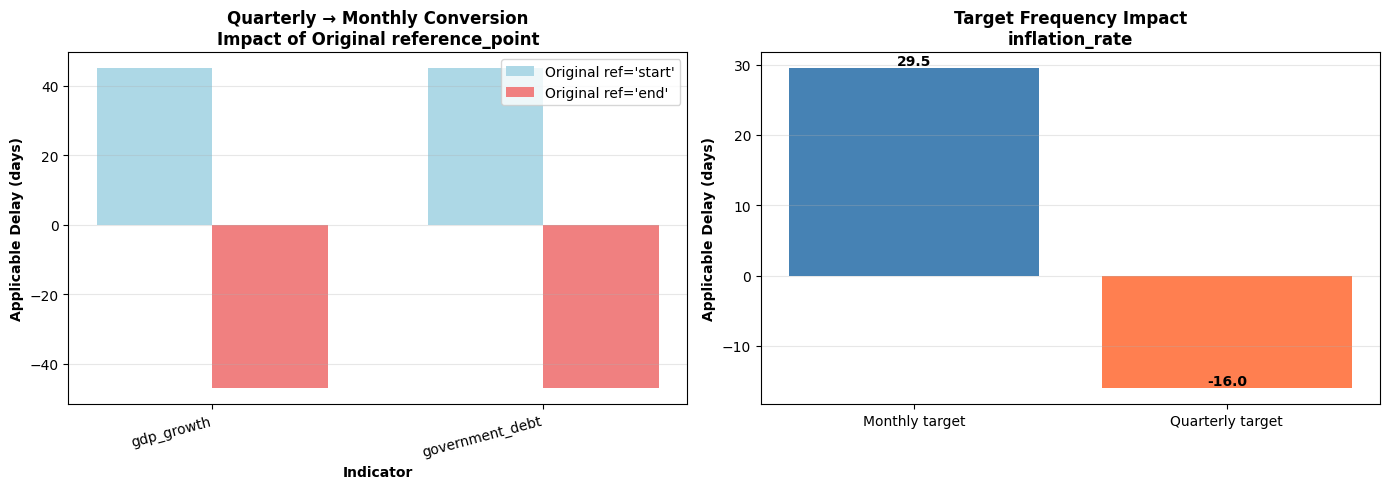

In [16]:
# Visualisation des conversions de fréquence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Quarterly → Monthly
ax1 = axes[0]
indicators_q = ['gdp_growth', 'government_debt']
delays_start = [applicable_q_to_m_start.loc[ind, 'applicable_delay'] for ind in indicators_q]
delays_end = [applicable_q_to_m_end.loc[ind, 'applicable_delay'] for ind in indicators_q]

x = np.arange(len(indicators_q))
width = 0.35

bars1 = ax1.bar(x - width/2, delays_start, width, label="Original ref='start'", color='lightblue')
bars2 = ax1.bar(x + width/2, delays_end, width, label="Original ref='end'", color='lightcoral')

ax1.set_xlabel('Indicator', fontweight='bold')
ax1.set_ylabel('Applicable Delay (days)', fontweight='bold')
ax1.set_title('Quarterly → Monthly Conversion\nImpact of Original reference_point', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(indicators_q, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Graphique 2: Comparaison Monthly vs Quarterly target
ax2 = axes[1]
indicator_sample = 'inflation_rate'
delay_monthly = applicable_delays.loc[indicator_sample, 'applicable_delay']
delay_quarterly = applicable_m_to_q.loc[indicator_sample, 'applicable_delay']

bars = ax2.bar(['Monthly target', 'Quarterly target'], [delay_monthly, delay_quarterly], 
               color=['steelblue', 'coral'])
ax2.set_ylabel('Applicable Delay (days)', fontweight='bold')
ax2.set_title(f'Target Frequency Impact\n{indicator_sample}', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Annotation des valeurs
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 2.3. Multi-fréquences avec liste de fréquences cibles

Lorsque vous avez des indicateurs à fréquences différentes, vous pouvez spécifier une fréquence cible différente pour chaque indicateur en passant une liste à `target_frequency`.

In [17]:
# Création d'un dataset mixte avec indicateurs mensuels et trimestriels
# Combinons les délais détectés pour les indicateurs mensuels et trimestriels
delays_mixed = pd.concat([delays_basic, delays_q_end])

print("Mixed frequency dataset:")
print(delays_mixed.groupby('column')[['frequency']].first())
print(f"\nTotal observations: {len(delays_mixed)}")

# Approche 1: Fréquence cible unique (convertit tout vers monthly)
applicable_single_freq = calculate_applicable_delay(
    publication_delays=delays_mixed,
    target_reference_point='end',
    target_frequency='monthly',  # Fréquence unique pour tous
    aggregation_method='median'
)

print("\n" + "="*80)
print("Approach 1: Single target frequency (all to monthly)")
print("="*80)
print(applicable_single_freq[['applicable_delay', 'target_frequency', 'n_observations']])

# Approche 2: Liste de fréquences cibles (garde la fréquence originale de chaque indicateur)
# On doit spécifier la fréquence pour chaque indicateur dans l'ordre
indicators = delays_mixed.index.get_level_values(0).unique().tolist()
print(f"\n\nIndicators: {indicators}")

# Créons une liste de fréquences: monthly pour les 3 premiers, quarterly pour les 2 derniers
target_freqs = ['monthly', 'monthly', 'monthly', 'quarterly', 'quarterly']

applicable_multi_freq = calculate_applicable_delay(
    publication_delays=delays_mixed,
    target_reference_point='end',
    target_frequency=target_freqs,  # Liste de fréquences
    indicators=indicators,  # Ordre des indicateurs
    aggregation_method='median'
)

print("\n" + "="*80)
print("Approach 2: Multiple target frequencies (preserve original)")
print("="*80)
print(applicable_multi_freq[['applicable_delay', 'target_frequency', 'n_observations']])

print("\n" + "="*80)
print("Comparison:")
print("="*80)
print("With a single target frequency, all indicators are converted to the same frequency.")
print("With a list of target frequencies, each indicator can maintain its original frequency.")

Mixed frequency dataset:
                       frequency
column                          
gdp_growth             quarterly
government_debt        quarterly
industrial_production    monthly
inflation_rate           monthly
unemployment_rate        monthly

Total observations: 8

Approach 1: Single target frequency (all to monthly)
                       applicable_delay target_frequency  n_observations
column                                                                  
gdp_growth                        -47.0          monthly               1
government_debt                   -47.0          monthly               1
industrial_production              29.5          monthly               2
inflation_rate                     29.5          monthly               2
unemployment_rate                  29.5          monthly               2


Indicators: ['unemployment_rate', 'inflation_rate', 'industrial_production', 'government_debt', 'gdp_growth']

Approach 2: Multiple target frequencies (pr

### 2.4. Méthodes d'agrégation

Le paramètre `aggregation_method` détermine comment les multiples observations sont agrégées en un seul délai applicable:

- **`'median'`** (recommandé): Robuste aux valeurs extrêmes
- **`'mean'`**: Moyenne de tous les délais
- **`'max'`**: Approche conservative (garantit que toutes les données sont disponibles)
- **`'min'`**: Approche optimiste (premier délai possible)
- **Fonction personnalisée**: Accepte aussi un callable

In [18]:
# Comparaison de différentes méthodes d'agrégation
methods = ['median', 'mean', 'max', 'min']
results = {}

for method in methods:
    result = calculate_applicable_delay(
        publication_delays=delays_basic,
        target_reference_point='end',
        target_frequency='monthly',
        aggregation_method=method
    )
    results[method] = result

# Création d'un tableau comparatif
comparison_df = pd.DataFrame({
    method: results[method]['applicable_delay'] 
    for method in methods
})

print("="*80)
print("Comparison of aggregation methods")
print("="*80)
print(comparison_df)
print("\n" + "="*80)
print("Analysis:")
print("="*80)
for indicator in comparison_df.index:
    delays = comparison_df.loc[indicator]
    print(f"\n{indicator}:")
    print(f"  Range: {delays['min']:.1f} - {delays['max']:.1f} days (spread: {delays['max'] - delays['min']:.1f} days)")
    print(f"  Median: {delays['median']:.1f} days (robust choice)")
    print(f"  Mean: {delays['mean']:.1f} days")
    
print("\n" + "="*80)
print("Use cases:")
print("="*80)
print("- median: Recommended for most cases (robust to outliers)")
print("- mean: When you want to account for all observations equally")
print("- max: Conservative approach (ensures all data will be available)")
print("- min: Optimistic approach (earliest possible access to data)")

Comparison of aggregation methods
                       median  mean  max  min
column                                       
industrial_production    29.5  29.5   45   14
inflation_rate           29.5  29.5   45   14
unemployment_rate        29.5  29.5   45   14

Analysis:

industrial_production:
  Range: 14.0 - 45.0 days (spread: 31.0 days)
  Median: 29.5 days (robust choice)
  Mean: 29.5 days

inflation_rate:
  Range: 14.0 - 45.0 days (spread: 31.0 days)
  Median: 29.5 days (robust choice)
  Mean: 29.5 days

unemployment_rate:
  Range: 14.0 - 45.0 days (spread: 31.0 days)
  Median: 29.5 days (robust choice)
  Mean: 29.5 days

Use cases:
- median: Recommended for most cases (robust to outliers)
- mean: When you want to account for all observations equally
- max: Conservative approach (ensures all data will be available)
- min: Optimistic approach (earliest possible access to data)


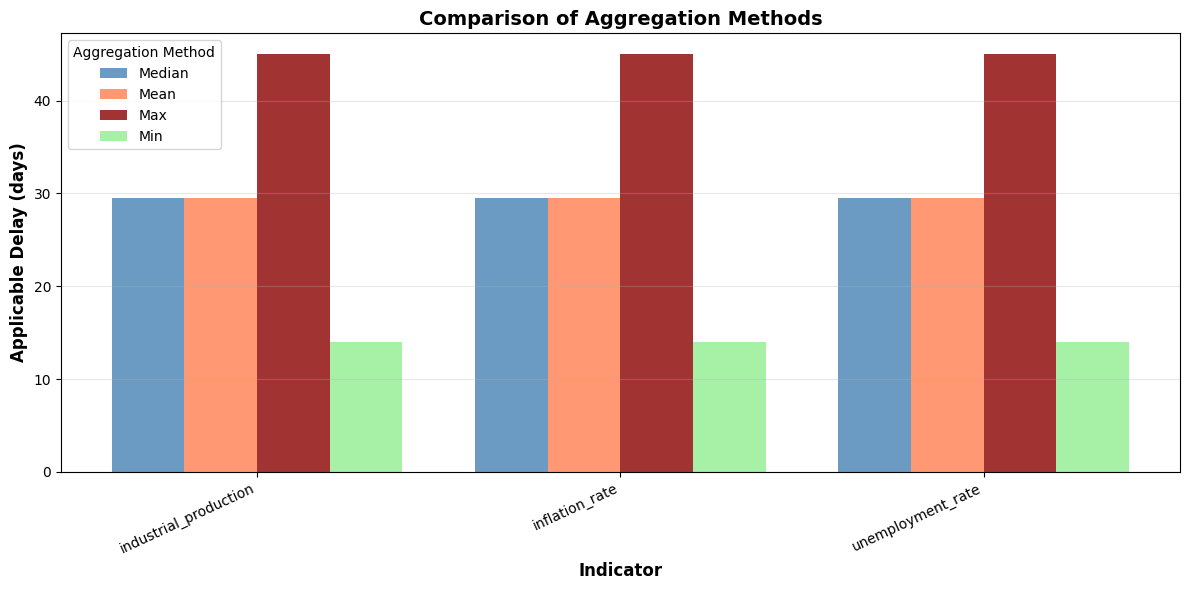


Key observation:
Max is always >= Median >= Min, showing the range of possible delay choices.


In [19]:
# Visualisation des méthodes d'agrégation
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df.index))
width = 0.2

colors = ['steelblue', 'coral', 'darkred', 'lightgreen']
for i, method in enumerate(methods):
    offset = (i - len(methods)/2 + 0.5) * width
    bars = ax.bar(x + offset, comparison_df[method], width, label=method.capitalize(), 
                   color=colors[i], alpha=0.8)

ax.set_xlabel('Indicator', fontweight='bold', fontsize=12)
ax.set_ylabel('Applicable Delay (days)', fontweight='bold', fontsize=12)
ax.set_title('Comparison of Aggregation Methods', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=25, ha='right')
ax.legend(title='Aggregation Method', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observation:")
print(f"Max is always >= Median >= Min, showing the range of possible delay choices.")

### 2.5. Agrégation par panel vs agrégation globale

Pour les données de panel, le paramètre `aggregate_by_panel` contrôle la granularité de l'agrégation:

- **`aggregate_by_panel=False`** (défaut): Agrégation globale sur toutes les entités → Un délai par indicateur
- **`aggregate_by_panel=True`**: Agrégation par entité → Un délai par (entité, indicateur)

In [20]:
# Utilisons les délais de panel détectés précédemment (delays_panel)
print("Panel delays structure:")
print(f"Index names: {delays_panel.index.names}")
print(f"Number of observations: {len(delays_panel)}")
print(f"Countries: {delays_panel.index.get_level_values(0).unique().tolist()}")
print(f"Indicators: {delays_panel.index.get_level_values(1).unique().tolist()}")

# Approche 1: Agrégation globale (un délai par indicateur)
applicable_global = calculate_applicable_delay(
    publication_delays=delays_panel,
    target_reference_point='end',
    target_frequency='monthly',
    aggregate_by_panel=False,  # Agrégation globale
    aggregation_method='median'
)

print("\n" + "="*80)
print("Approach 1: Global aggregation (aggregate_by_panel=False)")
print("="*80)
print(applicable_global)
print("\nResult: One delay per indicator (aggregated across all countries)")

# Approche 2: Agrégation par pays (un délai par (pays, indicateur))
applicable_by_panel = calculate_applicable_delay(
    publication_delays=delays_panel,
    target_reference_point='end',
    target_frequency='monthly',
    aggregate_by_panel=True,  # Agrégation par pays
    aggregation_method='median'
)

print("\n" + "="*80)
print("Approach 2: Panel-level aggregation (aggregate_by_panel=True)")
print("="*80)
print(applicable_by_panel)
print("\nResult: One delay per (country, indicator) combination")

print("\n" + "="*80)
print("Comparison:")
print("="*80)
print(f"Global aggregation: {len(applicable_global)} delays (one per indicator)")
print(f"Panel-level aggregation: {len(applicable_by_panel)} delays (one per country-indicator pair)")
print(f"\nWith {len(delays_panel.index.get_level_values(0).unique())} countries and {len(delays_panel.index.get_level_values(1).unique())} indicators:")
print(f"Expected panel-level delays: {len(delays_panel.index.get_level_values(0).unique()) * len(delays_panel.index.get_level_values(1).unique())} = {len(applicable_by_panel)}")

Panel delays structure:
Index names: ['country', 'column']
Number of observations: 16
Countries: ['DE', 'FR', 'UK', 'US']
Indicators: ['unemployment_rate', 'inflation_rate']

Approach 1: Global aggregation (aggregate_by_panel=False)
                   applicable_delay unit target_frequency  \
column                                                      
inflation_rate                 29.5  day          monthly   
unemployment_rate              29.5  day          monthly   

                  target_reference_point  n_observations aggregation_method  
column                                                                       
inflation_rate                       end               8             median  
unemployment_rate                    end               8             median  

Result: One delay per indicator (aggregated across all countries)

Approach 2: Panel-level aggregation (aggregate_by_panel=True)
                           applicable_delay unit target_frequency  \
country col

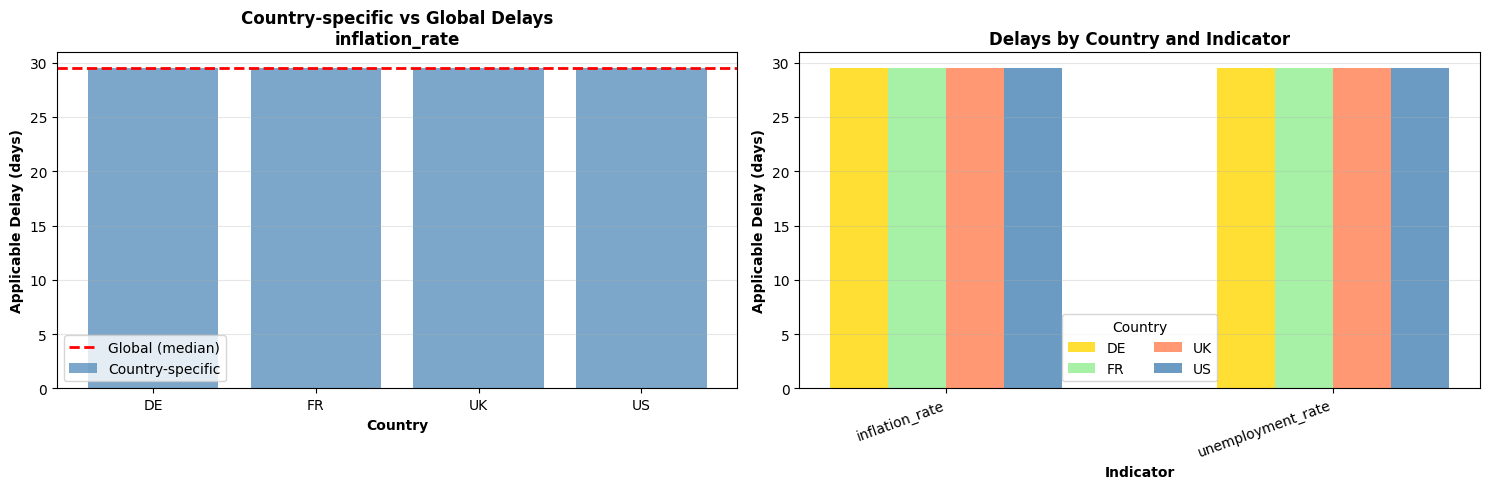


Key observation:
Different countries may have different publication delays for the same indicator.
Global aggregation provides a single representative delay, while panel-level aggregation
captures country-specific patterns.


In [21]:
# Visualisation: Comparaison des délais par pays vs global
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graphique 1: Délais par pays pour un indicateur
ax1 = axes[0]
indicator_sample = applicable_by_panel.index.get_level_values(1).unique()[0]
countries_delays = []
countries_names = []

for country in applicable_by_panel.index.get_level_values(0).unique():
    if (country, indicator_sample) in applicable_by_panel.index:
        countries_delays.append(applicable_by_panel.loc[(country, indicator_sample), 'applicable_delay'])
        countries_names.append(country)

# Ajout de la valeur globale
global_delay = applicable_global.loc[indicator_sample, 'applicable_delay']

bars = ax1.bar(countries_names, countries_delays, color='steelblue', alpha=0.7, label='Country-specific')
ax1.axhline(y=global_delay, color='red', linestyle='--', linewidth=2, label=f'Global (median)')
ax1.set_xlabel('Country', fontweight='bold')
ax1.set_ylabel('Applicable Delay (days)', fontweight='bold')
ax1.set_title(f'Country-specific vs Global Delays\n{indicator_sample}', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Graphique 2: Comparaison pour tous les indicateurs
ax2 = axes[1]
indicators = applicable_by_panel.index.get_level_values(1).unique()
x = np.arange(len(indicators))
width = 0.15

countries = applicable_by_panel.index.get_level_values(0).unique()
colors_map = {'US': 'steelblue', 'UK': 'coral', 'FR': 'lightgreen', 'DE': 'gold'}

for i, country in enumerate(countries):
    country_delays = [
        applicable_by_panel.loc[(country, ind), 'applicable_delay'] 
        if (country, ind) in applicable_by_panel.index else 0
        for ind in indicators
    ]
    offset = (i - len(countries)/2 + 0.5) * width
    ax2.bar(x + offset, country_delays, width, label=country, color=colors_map.get(country, 'gray'), alpha=0.8)

ax2.set_xlabel('Indicator', fontweight='bold')
ax2.set_ylabel('Applicable Delay (days)', fontweight='bold')
ax2.set_title('Delays by Country and Indicator', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(indicators, rotation=20, ha='right')
ax2.legend(title='Country', ncol=2)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observation:")
print("Different countries may have different publication delays for the same indicator.")
print("Global aggregation provides a single representative delay, while panel-level aggregation")
print("captures country-specific patterns.")

### 2.6. Fonction d'agrégation personnalisée

Le paramètre `aggregation_method` accepte aussi une fonction personnalisée (callable). Ceci permet d'implémenter des stratégies d'agrégation spécifiques.

In [22]:
# Définition de fonctions d'agrégation personnalisées

# Fonction 1: 90e percentile (approche conservative mais moins extrême que max)
def percentile_90(x):
    """Calculate 90th percentile"""
    return np.percentile(x, 90)

# Fonction 2: 75e percentile (Q3)
def percentile_75(x):
    """Calculate 75th percentile (Q3)"""
    return np.percentile(x, 75)

# Fonction 3: Moyenne tronquée (exclut les 10% extrêmes de chaque côté)
from scipy import stats
def trimmed_mean(x):
    """Calculate trimmed mean (exclude 10% extremes on each side)"""
    return stats.trim_mean(x, 0.1)

# Application des fonctions custom
custom_methods = {
    'median (default)': 'median',
    'P90 (conservative)': percentile_90,
    'P75 (Q3)': percentile_75,
    'Trimmed mean': trimmed_mean,
}

custom_results = {}
for name, method in custom_methods.items():
    result = calculate_applicable_delay(
        publication_delays=delays_basic,
        target_reference_point='end',
        target_frequency='monthly',
        aggregation_method=method
    )
    custom_results[name] = result

# Tableau comparatif
custom_comparison = pd.DataFrame({
    name: custom_results[name]['applicable_delay']
    for name in custom_methods.keys()
})

print("="*80)
print("Custom aggregation methods comparison")
print("="*80)
print(custom_comparison)

print("\n" + "="*80)
print("Analysis:")
print("="*80)
for indicator in custom_comparison.index:
    print(f"\n{indicator}:")
    print(f"  Median (default): {custom_comparison.loc[indicator, 'median (default)']:.1f} days")
    print(f"  P75 (Q3): {custom_comparison.loc[indicator, 'P75 (Q3)']:.1f} days")
    print(f"  P90 (conservative): {custom_comparison.loc[indicator, 'P90 (conservative)']:.1f} days")
    print(f"  Trimmed mean: {custom_comparison.loc[indicator, 'Trimmed mean']:.1f} days")

print("\n" + "="*80)
print("Use cases for custom functions:")
print("="*80)
print("- P90: Conservative approach without using the absolute maximum")
print("- P75: Moderately conservative (upper quartile)")
print("- Trimmed mean: Robust to extreme outliers while accounting for all typical values")

Custom aggregation methods comparison
                       median (default)  P90 (conservative)  P75 (Q3)  \
column                                                                  
industrial_production              29.5                41.9     37.25   
inflation_rate                     29.5                41.9     37.25   
unemployment_rate                  29.5                41.9     37.25   

                       Trimmed mean  
column                               
industrial_production          29.5  
inflation_rate                 29.5  
unemployment_rate              29.5  

Analysis:

industrial_production:
  Median (default): 29.5 days
  P75 (Q3): 37.2 days
  P90 (conservative): 41.9 days
  Trimmed mean: 29.5 days

inflation_rate:
  Median (default): 29.5 days
  P75 (Q3): 37.2 days
  P90 (conservative): 41.9 days
  Trimmed mean: 29.5 days

unemployment_rate:
  Median (default): 29.5 days
  P75 (Q3): 37.2 days
  P90 (conservative): 41.9 days
  Trimmed mean: 29.5 days

Use

## 3. Cas d'usage avancés

Cette section présente des scénarios plus complexes combinant plusieurs fonctionnalités.

### 3.1. Panel data + Multi-fréquences

Scénario le plus complexe: données de panel avec indicateurs à fréquences différentes.

In [23]:
# Création d'un dataset de panel avec indicateurs mensuels ET trimestriels
# Simulons la détection de délais pour ce cas complexe

# Panel mensuel existant et nouveau
existing_panel_m = existing_panel_monthly.copy()
new_panel_m = new_panel_monthly.copy()

# Panel trimestriel: générons d'abord les données
existing_panel_q_list = []
new_panel_q_list = []

for i, country in enumerate(countries):
    np.random.seed(42 + i)
    quarterly_panel = pd.DataFrame({
        'date': quarterly_dates,
        'country': country,
        'gdp_growth': generate_economic_series(quarterly_dates, 2.5 + i*0.2, 0.0005, 0.015),
    })
    existing_panel_q_list.append(quarterly_panel[quarterly_panel['date'] <= '2023-04-01'])
    new_panel_q_list.append(quarterly_panel[quarterly_panel['date'] <= '2023-07-01'])

existing_panel_q = pd.concat(existing_panel_q_list, ignore_index=True)
new_panel_q = pd.concat(new_panel_q_list, ignore_index=True)

# Détection des délais pour les deux fréquences
delays_panel_m = compare_and_detect_delays(
    new_data=new_panel_m,
    existing_data=existing_panel_m,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='day',
    panel_cols=['country'],
    time_col="date"
)

delays_panel_q = compare_and_detect_delays(
    new_data=new_panel_q,
    existing_data=existing_panel_q,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='day',
    panel_cols=['country'],
    time_col="date"
)

# Combinaison des deux datasets
delays_panel_mixed = pd.concat([delays_panel_m, delays_panel_q])

print("Mixed frequency panel data structure:")
print(f"Total observations: {len(delays_panel_mixed)}")
print(f"\nBy frequency:")
print(delays_panel_mixed.groupby('frequency').size())
print(f"\nBy country:")
print(delays_panel_mixed.groupby(level=1).size())
print(f"\nIndicators: {delays_panel_mixed.index.get_level_values(1).unique().tolist()}")

Mixed frequency panel data structure:
Total observations: 20

By frequency:
frequency
monthly      16
quarterly     4
dtype: int64

By country:
column
gdp_growth           4
inflation_rate       8
unemployment_rate    8
dtype: int64

Indicators: ['unemployment_rate', 'inflation_rate', 'gdp_growth']


In [24]:
# Calcul des délais applicables pour ce cas complexe

# Approche 1: Global aggregation avec conversion vers monthly pour tout
applicable_complex_global = calculate_applicable_delay(
    publication_delays=delays_panel_mixed,
    target_reference_point='end',
    target_frequency='monthly',  # Tout vers monthly
    aggregate_by_panel=False,  # Agrégation globale
    aggregation_method='median'
)

print("="*80)
print("Approach 1: Global aggregation + single frequency (all to monthly)")
print("="*80)
print(applicable_complex_global)
print("\nResult: One delay per indicator (aggregated across all countries)")

# Approche 2: Panel-level aggregation avec préservation des fréquences
indicators_mixed = delays_panel_mixed.index.get_level_values(1).unique().tolist()
# Déterminer les fréquences originales de chaque indicateur
target_freqs_mixed = []
for ind in indicators_mixed:
    freq = delays_panel_mixed[delays_panel_mixed.index.get_level_values(1) == ind]['frequency'].iloc[0]
    target_freqs_mixed.append(freq)

applicable_complex_panel = calculate_applicable_delay(
    publication_delays=delays_panel_mixed,
    target_reference_point='end',
    target_frequency=target_freqs_mixed,  # Fréquence spécifique par indicateur
    indicators=indicators_mixed,
    aggregate_by_panel=True,  # Agrégation par pays
    aggregation_method='median'
)

print("\n" + "="*80)
print("Approach 2: Panel-level aggregation + preserve original frequencies")
print("="*80)
print(applicable_complex_panel)
print("\nResult: One delay per (country, indicator) with original frequencies preserved")

print("\n" + "="*80)
print("Summary:")
print("="*80)
print(f"Approach 1 produces {len(applicable_complex_global)} delays (global)")
print(f"Approach 2 produces {len(applicable_complex_panel)} delays (country-specific)")
print(f"\nApproach 2 captures:")
print(f"  - {len(countries)} countries")
print(f"  - {len(indicators_mixed)} indicators")
print(f"  - {len(countries) * len(indicators_mixed)} combinations")

Approach 1: Global aggregation + single frequency (all to monthly)
                   applicable_delay unit target_frequency  \
column                                                      
gdp_growth                    -47.0  day          monthly   
inflation_rate                 29.5  day          monthly   
unemployment_rate              29.5  day          monthly   

                  target_reference_point  n_observations aggregation_method  
column                                                                       
gdp_growth                           end               4             median  
inflation_rate                       end               8             median  
unemployment_rate                    end               8             median  

Result: One delay per indicator (aggregated across all countries)

Approach 2: Panel-level aggregation + preserve original frequencies
                           applicable_delay unit target_frequency  \
country column                  

### 3.2. Conversions d'unités

Les délais peuvent être exprimés dans différentes unités. Les paramètres `delay_unit` (dans `compare_and_detect_delays`) et `output_unit` (dans `calculate_applicable_delay`) permettent de contrôler l'unité utilisée.

In [25]:
# Détection de délais avec différentes unités

# Unité 1: jours (default)
delays_days = compare_and_detect_delays(
    new_data=new_df,
    existing_data=existing_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='day'  # ou 'D'
)

# Unité 2: secondes
delays_seconds = compare_and_detect_delays(
    new_data=new_df,
    existing_data=existing_df,
    download_date=download_date,
    detection_mode='new_only',
    reference_point='end',
    delay_unit='second'  # ou 's'
)

print("="*80)
print("Delays in different units (compare_and_detect_delays)")
print("="*80)
print("\nIn days:")
print(delays_days[['release_delay', 'unit']].head())
print("\nIn seconds:")
print(delays_seconds[['release_delay', 'unit']].head())

# Conversion d'unités avec calculate_applicable_delay
applicable_days = calculate_applicable_delay(
    publication_delays=delays_days,
    target_reference_point='end',
    target_frequency='monthly',
    aggregation_method='median',
    output_unit=None  # Garde l'unité originale (days)
)

applicable_seconds = calculate_applicable_delay(
    publication_delays=delays_days,
    target_reference_point='end',
    target_frequency='monthly',
    aggregation_method='median',
    output_unit='second'  # Convertit vers secondes
)

print("\n" + "="*80)
print("Applicable delays in different units (calculate_applicable_delay)")
print("="*80)
print("\nOriginal unit (days):")
print(applicable_days[['applicable_delay', 'unit']])
print("\nConverted to seconds:")
print(applicable_seconds[['applicable_delay', 'unit']])

# Tableau comparatif des conversions
conversion_table = pd.DataFrame({
    'Days': applicable_days['applicable_delay'],
    'Seconds': applicable_seconds['applicable_delay'],
    'Seconds (calculated)': applicable_days['applicable_delay'] * 24 * 3600
})

print("\n" + "="*80)
print("Unit conversion verification:")
print("="*80)
print(conversion_table)
print("\nVerification: Seconds = Days × 24 × 3600 ✓")

Delays in different units (compare_and_detect_delays)

In days:
                       release_delay unit
column                                   
unemployment_rate               45.0  day
unemployment_rate               14.0  day
inflation_rate                  45.0  day
inflation_rate                  14.0  day
industrial_production           45.0  day

In seconds:
                       release_delay    unit
column                                      
unemployment_rate          3888000.0  second
unemployment_rate          1209600.0  second
inflation_rate             3888000.0  second
inflation_rate             1209600.0  second
industrial_production      3888000.0  second

Applicable delays in different units (calculate_applicable_delay)

Original unit (days):
                       applicable_delay unit
column                                      
industrial_production              29.5  day
inflation_rate                     29.5  day
unemployment_rate                  29.5  day

## Conclusion

Ce notebook a illustré l'utilisation des deux fonctions principales du module `delays`:

### `compare_and_detect_delays`
Détecte les nouvelles publications et calcule les délais bruts.

**Paramètres clés:**
- `detection_mode`: `'new_only'` (nouvelles publications) vs `'all_changes'` (+ révisions)
- `reference_point`: `'start'` ou `'end'` (impact majeur sur les valeurs de délais)
- `delay_unit`: `'day'`, `'second'`, `'microsecond'`
- `panel_cols`: Liste pour données de panel

### `calculate_applicable_delay`
Agrège les délais détectés en un délai applicable unique par indicateur.

**Paramètres clés:**
- `target_frequency`: String ou liste pour multi-fréquences
- `target_reference_point`: Point de référence cible
- `aggregation_method`: `'median'`, `'mean'`, `'max'`, `'min'`, ou fonction custom
- `aggregate_by_panel`: `False` (global) ou `True` (par entité)
- `output_unit`: Conversion d'unité optionnelle

### Recommandations d'usage

1. **Par défaut**: `detection_mode='new_only'`, `reference_point='end'`, `aggregation_method='median'`
2. **Tracking de révisions**: `detection_mode='all_changes'`
3. **Approche conservative**: `aggregation_method='max'`
4. **Approche optimiste**: `aggregation_method='min'`
5. **Données panel**: Choisir entre agrégation globale ou par entité selon le cas d'usage